In [29]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

filename = "../data/raw/ICPSR_38506-V2.zip"

# Open the ZIP file and read the specific TSV file
with zipfile.ZipFile(filename, 'r') as zip_ref:
    with zip_ref.open('ICPSR_38506/DS0001/38506-0001-Data.tsv') as file:
        data = pd.read_csv(file, sep='\t')

print(f"Data loaded successfully!")
print(f"Shape: {data.shape}")
data.head()

Data loaded successfully!
Shape: (35278, 18)


,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001,2000,,,,,,,4942,11993,,,.2918216586113,.7081783413887,,,,
1,1001,2002,,,,,,,,,3819,10687,,,.2632703781128,.7367296218872,,
2,1001,2004,28100,20119,34420,.816385805607,.584514796734,.715978622437,4758,15196,3960,15728,.2384484261274,.7615515589714,.2011377513409,.7988622784615,,
3,1001,2006,29724,0,36140,.822468161583,0,0,,,,,,,,,.2582950294018,.7417049407959
4,1001,2008,33536,23714,39580,.847296595573,.599141001701,.707120716572,6093,17403,5316,17941,.2593207359314,.7406792640686,.2285763472319,.771423637867,.2423373311758,.757662653923


In [30]:
# Data type conversion and cleaning
print("Converting data types...")

# Replace empty strings with NaN
import numpy as np
data = data.replace('', np.nan)

# Convert numeric columns
numeric_columns = ['REG_VOTERS', 'BALLOTS_CAST', 'CVAP', 
                   'REG_VOTERS_PCT', 'VOTER_TURNOUT_PCT', 'REG_VOTER_TURNOUT_PCT',
                   'PRES_DEM_VOTES', 'PRES_REP_VOTES', 'SEN_DEM_VOTES', 'SEN_REP_VOTES',
                   'PRES_DEM_RATIO', 'PRES_REP_RATIO', 'SEN_DEM_RATIO', 'SEN_REP_RATIO',
                   'PARTISAN_INDEX_DEM', 'PARTISAN_INDEX_REP']

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("\nData types after conversion:")
print(data.dtypes)

print("\nMissing values per column:")
print(data.isnull().sum())

Converting data types...

Data types after conversion:
STCOFIPS10                 int64
YEAR                       int64
REG_VOTERS               float64
BALLOTS_CAST             float64
CVAP                     float64
REG_VOTERS_PCT           float64
VOTER_TURNOUT_PCT        float64
REG_VOTER_TURNOUT_PCT    float64
PRES_DEM_VOTES           float64
PRES_REP_VOTES           float64
SEN_DEM_VOTES            float64
SEN_REP_VOTES            float64
PRES_DEM_RATIO           float64
PRES_REP_RATIO           float64
SEN_DEM_RATIO            float64
SEN_REP_RATIO            float64
PARTISAN_INDEX_DEM       float64
PARTISAN_INDEX_REP       float64
dtype: object

Missing values per column:
STCOFIPS10                   0
YEAR                         0
REG_VOTERS                4272
BALLOTS_CAST              4272
CVAP                      4163
REG_VOTERS_PCT            4276
VOTER_TURNOUT_PCT         4276
REG_VOTER_TURNOUT_PCT     4552
PRES_DEM_VOTES           16603
PRES_REP_VOTES           16603

In [31]:
# Display basic information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nNumber of rows: {data.shape[0]:,}")
print(f"Number of columns: {data.shape[1]}")
print(f"\nColumn names and types:")
data.info()

DATASET INFORMATION

Number of rows: 35,278
Number of columns: 18

Column names and types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35278 entries, 0 to 35277
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   STCOFIPS10             35278 non-null  int64  
 1   YEAR                   35278 non-null  int64  
 2   REG_VOTERS             31006 non-null  float64
 3   BALLOTS_CAST           31006 non-null  float64
 4   CVAP                   31115 non-null  float64
 5   REG_VOTERS_PCT         31002 non-null  float64
 6   VOTER_TURNOUT_PCT      31002 non-null  float64
 7   REG_VOTER_TURNOUT_PCT  30726 non-null  float64
 8   PRES_DEM_VOTES         18675 non-null  float64
 9   PRES_REP_VOTES         18675 non-null  float64
 10  SEN_DEM_VOTES          16724 non-null  float64
 11  SEN_REP_VOTES          16724 non-null  float64
 12  PRES_DEM_RATIO         18675 non-null  float64
 13  PRES_REP_RATIO 

In [32]:
# Summary statistics for numerical columns
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
data.describe()


SUMMARY STATISTICS


,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
count,35278.000000,35278.000000,3.100600e+04,3.100600e+04,3.111500e+04,31002.000000,31002.000000,30726.000000,1.867500e+04,1.867500e+04,1.672400e+04,16724.000000,18675.000000,18675.000000,16699.000000,16699.000000,26689.000000,26689.000000
mean,30634.726345,2011.530302,6.110200e+04,3.564164e+04,7.286495e+04,0.830199,0.506426,0.550207,2.315147e+04,2.196415e+04,1.739566e+04,18296.012397,0.381782,0.618218,0.379828,0.620172,0.392662,0.607338
std,15030.530569,6.738283,1.871341e+05,1.054692e+05,2.202954e+05,0.195072,0.173693,0.295002,8.870717e+04,5.620166e+04,6.198764e+04,45021.939112,0.148929,0.148929,0.171488,0.171488,0.146473,0.146473
min,1001.000000,2000.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000,-1.000000,-1.000000,4.000000e+00,5.400000e+01,0.000000e+00,0.000000,0.031136,0.043048,0.000000,0.000000,0.024595,0.073882
25%,19025.000000,2006.000000,6.686250e+03,3.753000e+03,8.442500e+03,0.791766,0.419125,0.488999,1.580500e+03,3.050500e+03,1.254750e+03,2399.750000,0.271418,0.523686,0.255642,0.515212,0.286018,0.513989
50%,29213.000000,2012.000000,1.590950e+04,9.011500e+03,1.960300e+04,0.872182,0.526475,0.607054,4.058000e+03,6.900000e+03,3.402000e+03,5813.000000,0.372917,0.627083,0.360518,0.639482,0.386798,0.613202
75%,46025.000000,2018.000000,4.107350e+04,2.399075e+04,5.124500e+04,0.945459,0.621064,0.700514,1.172350e+04,1.809250e+04,9.513000e+03,15343.250000,0.476314,0.728582,0.484788,0.744358,0.486011,0.713982
max,56045.000000,2022.000000,7.412146e+06,4.263059e+06,7.843598e+06,0.980000,0.980000,0.980000,3.122322e+06,2.986995e+06,1.940493e+06,984203.000000,0.956952,0.968864,1.000000,1.000000,0.926118,0.975405



MISSING VALUES ANALYSIS
               Column  Missing_Count  Missing_Percentage
        SEN_DEM_RATIO          18579           52.664550
        SEN_REP_RATIO          18579           52.664550
        SEN_REP_VOTES          18554           52.593684
        SEN_DEM_VOTES          18554           52.593684
       PRES_DEM_VOTES          16603           47.063326
       PRES_REP_VOTES          16603           47.063326
       PRES_DEM_RATIO          16603           47.063326
       PRES_REP_RATIO          16603           47.063326
   PARTISAN_INDEX_DEM           8589           24.346618
   PARTISAN_INDEX_REP           8589           24.346618
REG_VOTER_TURNOUT_PCT           4552           12.903226
       REG_VOTERS_PCT           4276           12.120869
    VOTER_TURNOUT_PCT           4276           12.120869
           REG_VOTERS           4272           12.109530
         BALLOTS_CAST           4272           12.109530
                 CVAP           4163           11.800556


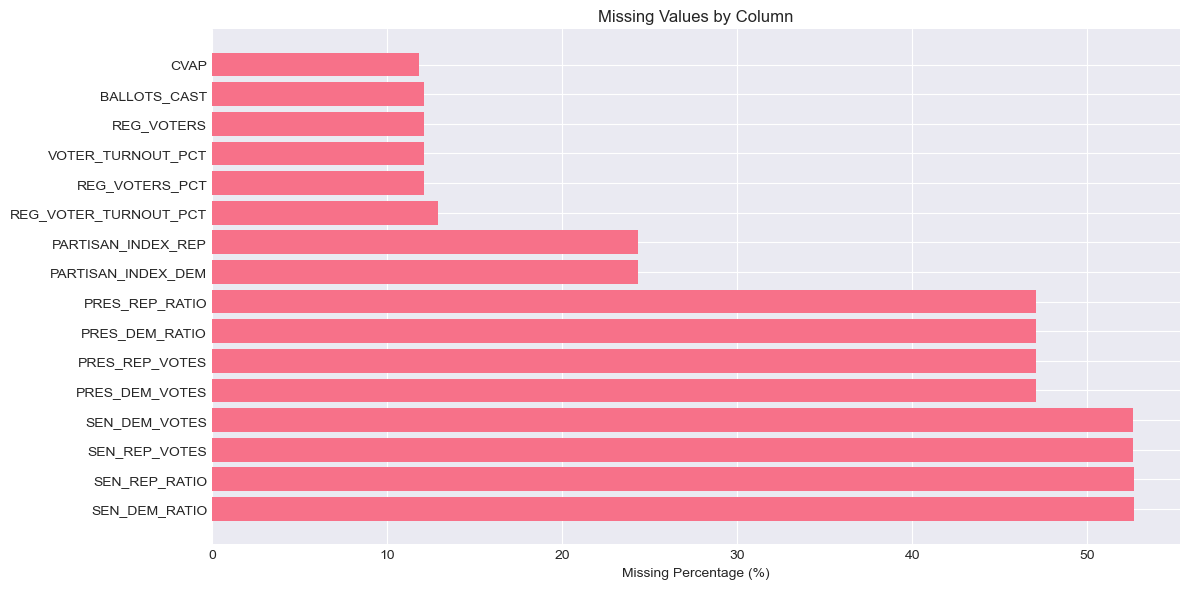

In [33]:
# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(missing_df.to_string(index=False))

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Column'], missing_df['Missing_Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [34]:
# Display first few rows
print("\n" + "=" * 80)
print("FIRST 10 ROWS")
print("=" * 80)
data.head(10)


FIRST 10 ROWS


,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001,2000,NaN,NaN,NaN,NaN,NaN,NaN,4942.0,11993.0,NaN,NaN,0.291822,0.708178,NaN,NaN,NaN,NaN
1,1001,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3819.0,10687.0,NaN,NaN,0.263270,0.736730,NaN,NaN
2,1001,2004,28100.0,20119.0,34420.0,0.816386,0.584515,0.715979,4758.0,15196.0,3960.0,15728.0,0.238448,0.761552,0.201138,0.798862,NaN,NaN
3,1001,2006,29724.0,0.0,36140.0,0.822468,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258295,0.741705
4,1001,2008,33536.0,23714.0,39580.0,0.847297,0.599141,0.707121,6093.0,17403.0,5316.0,17941.0,0.259321,0.740679,0.228576,0.771424,0.242337,0.757663
5,1001,2010,34727.0,18180.0,39580.0,0.877388,0.459323,0.523512,NaN,NaN,3978.0,13979.0,NaN,NaN,0.221529,0.778471,0.228424,0.771576
6,1001,2012,37170.0,24065.0,39580.0,0.939111,0.608009,0.647431,6363.0,17379.0,NaN,NaN,0.268006,0.731994,NaN,NaN,0.244495,0.755505
7,1001,2014,33806.0,33806.0,41015.0,0.824235,0.824235,0.980000,NaN,NaN,0.0,10345.0,NaN,NaN,0.000000,1.000000,0.183371,0.816629
8,1001,2016,38187.0,25146.0,41015.0,0.931050,0.613093,0.658496,5936.0,18172.0,6331.0,18220.0,0.246225,0.753775,0.257871,0.742129,0.185396,0.814604
9,1001,2018,39770.0,19873.0,44995.0,0.883876,0.441671,0.499698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Found 18 numerical columns


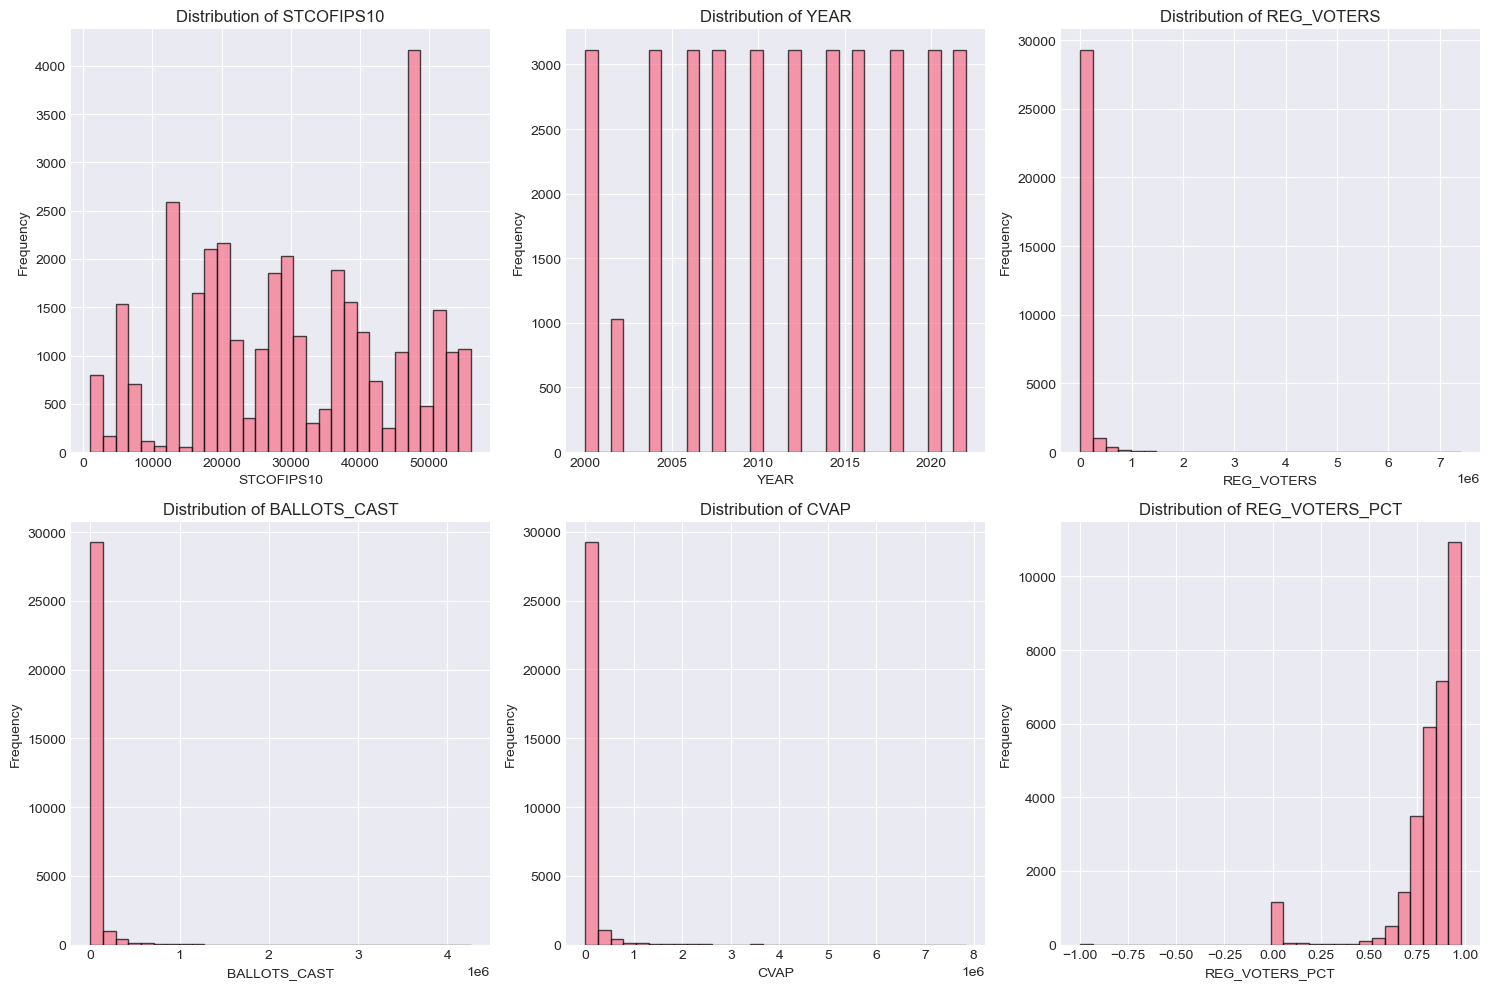

In [35]:
# Plot distributions of numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()

if len(numerical_cols) > 0:
    print(f"\nFound {len(numerical_cols)} numerical columns")
    
    # Plot first 6 numerical columns
    n_plots = min(6, len(numerical_cols))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(numerical_cols[:n_plots]):
        axes[idx].hist(data[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    # Hide empty subplots
    for idx in range(n_plots, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [36]:
# Analyze categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"\nFound {len(categorical_cols)} categorical columns")
    
    for col in categorical_cols[:5]:  # Show first 5 categorical columns
        print(f"\n{col}:")
        print(data[col].value_counts())
        print("-" * 40)

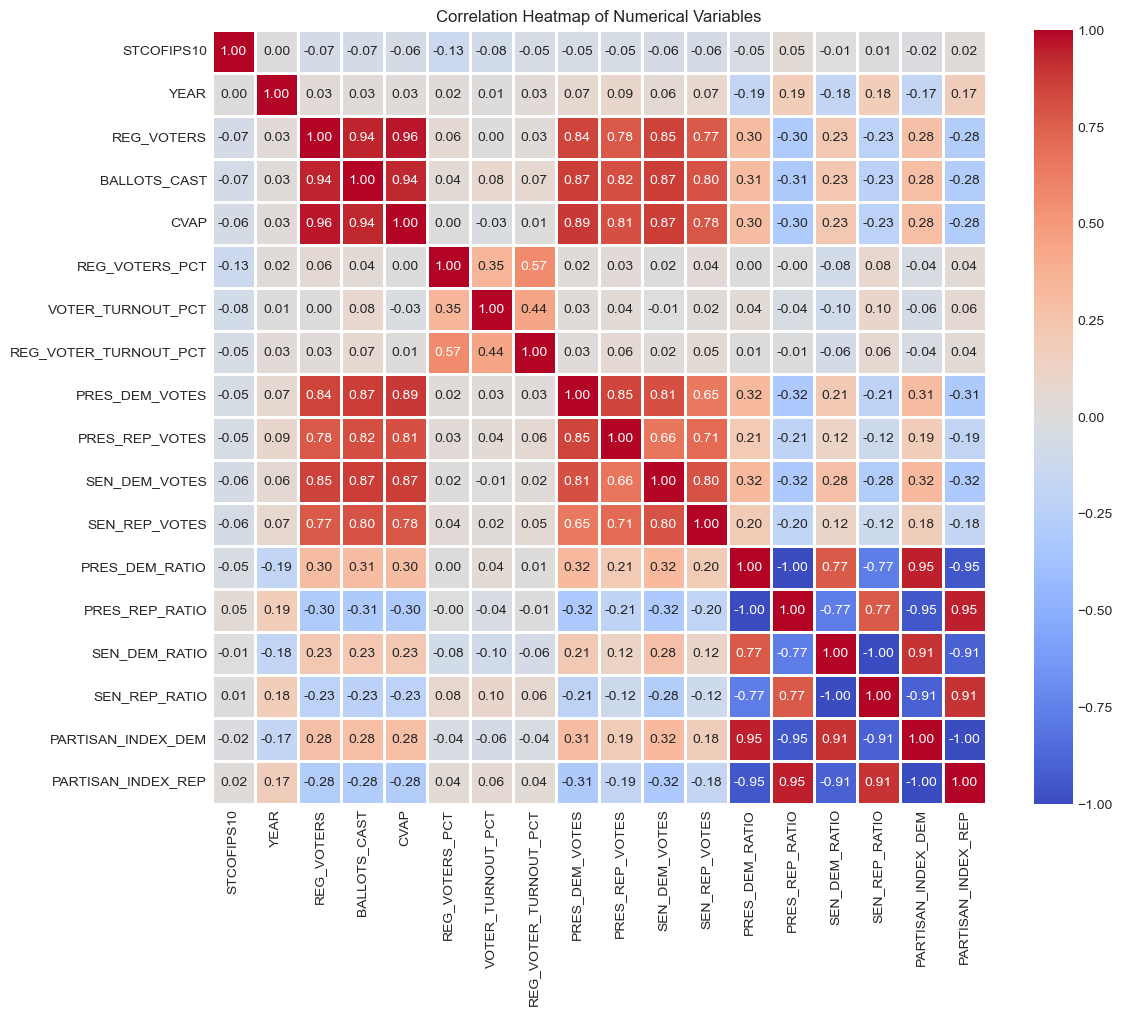

In [37]:
# Correlation heatmap for numerical columns
if len(numerical_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = data[numerical_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1)
    plt.title('Correlation Heatmap of Numerical Variables')
    plt.tight_layout()
    plt.show()

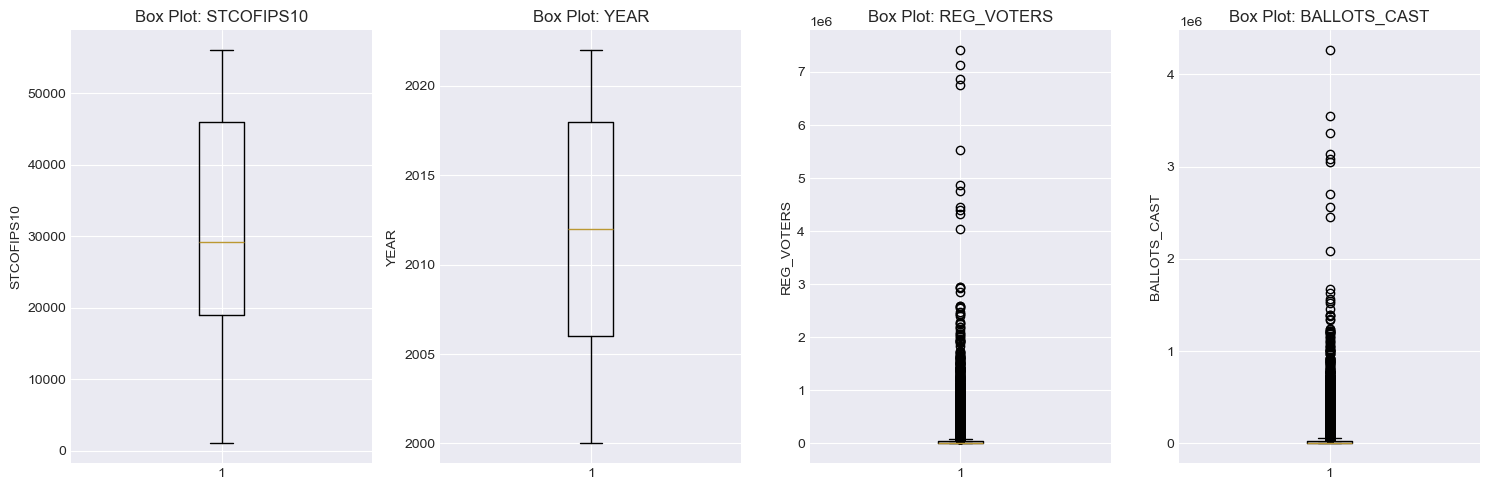

In [38]:
# Create some custom visualizations based on the data
# Box plots for numerical columns
if len(numerical_cols) > 0:
    n_plots = min(4, len(numerical_cols))
    fig, axes = plt.subplots(1, n_plots, figsize=(15, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    for idx, col in enumerate(numerical_cols[:n_plots]):
        axes[idx].boxplot(data[col].dropna())
        axes[idx].set_title(f'Box Plot: {col}')
        axes[idx].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

In [39]:
import os

# Prepare data for final analysis and save as Parquet file

# Create separate state and county FIPS codes from STCOFIPS10
# STCOFIPS10 format: First 2 digits = State FIPS, Last 3 digits = County FIPS
data['STATE_FIPS'] = (data['STCOFIPS10'] // 1000).astype(str).str.zfill(2)
data['COUNTY_FIPS'] = (data['STCOFIPS10'] % 1000).astype(str).str.zfill(3)
data['FIPS'] = data['STCOFIPS10'].astype(str).str.zfill(5)  # Full 5-digit FIPS code

# Select and rename columns for clarity
voting_pop_data = data[[
    'FIPS', 'STATE_FIPS', 'COUNTY_FIPS', 'YEAR',
    'CVAP', 'REG_VOTERS', 'BALLOTS_CAST',
    'REG_VOTERS_PCT', 'VOTER_TURNOUT_PCT', 'REG_VOTER_TURNOUT_PCT',
    'PRES_DEM_VOTES', 'PRES_REP_VOTES', 
    'SEN_DEM_VOTES', 'SEN_REP_VOTES',
    'PRES_DEM_RATIO', 'PRES_REP_RATIO',
    'SEN_DEM_RATIO', 'SEN_REP_RATIO',
    'PARTISAN_INDEX_DEM', 'PARTISAN_INDEX_REP'
]].copy()

# Display summary
print("=" * 80)
print("PREPARED DATA FOR EXPORT")
print("=" * 80)
print(f"\nTotal rows: {len(voting_pop_data):,}")
print(f"Year range: {voting_pop_data['YEAR'].min()} - {voting_pop_data['YEAR'].max()}")
print(f"Unique counties: {voting_pop_data['FIPS'].nunique():,}")
print(f"\nSample FIPS codes:")
print(voting_pop_data[['FIPS', 'STATE_FIPS', 'COUNTY_FIPS', 'YEAR']].head(10))

# Check for any data quality issues
print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)
print(f"\nRows with missing CVAP: {voting_pop_data['CVAP'].isna().sum():,}")
print(f"Rows with missing BALLOTS_CAST: {voting_pop_data['BALLOTS_CAST'].isna().sum():,}")

# Save as Parquet file
output_filename = '../data/processed/voting_population_cleaned.parquet'
try:
    voting_pop_data.to_parquet(output_filename, index=False, compression='snappy')
    print(f"\n{'='*80}")
    print(f"✓ Data successfully saved to: {output_filename}")
    print(f"{'='*80}")
    # Check file size
    print(f"\nFile size: {os.path.getsize(output_filename) / 1024:.2f} KB")
except ImportError:
    print("\nError: pyarrow or fastparquet is not installed. Saving as CSV instead.")
    output_csv = 'voting_population_cleaned.csv'
    voting_pop_data.to_csv(output_csv, index=False)
    print(f"✓ Data successfully saved to: {output_csv}")
except Exception as e:
    print(f"\nError saving file: {e}")

PREPARED DATA FOR EXPORT

Total rows: 35,278
Year range: 2000 - 2022
Unique counties: 3,115

Sample FIPS codes:
    FIPS STATE_FIPS COUNTY_FIPS  YEAR
0  01001         01         001  2000
1  01001         01         001  2002
2  01001         01         001  2004
3  01001         01         001  2006
4  01001         01         001  2008
5  01001         01         001  2010
6  01001         01         001  2012
7  01001         01         001  2014
8  01001         01         001  2016
9  01001         01         001  2018

DATA QUALITY CHECK

Rows with missing CVAP: 4,163
Rows with missing BALLOTS_CAST: 4,272

✓ Data successfully saved to: ../data/processed/voting_population_cleaned.parquet

File size: 2759.83 KB


Successfully loaded ../data/processed/voting_population_cleaned.parquet
Saving plots to ../plots/ directory...
Converting REG_VOTERS_PCT to percentage (multiplying by 100)
Converting VOTER_TURNOUT_PCT to percentage (multiplying by 100)
Converting REG_VOTER_TURNOUT_PCT to percentage (multiplying by 100)
Saved voter_turnout_trends.png


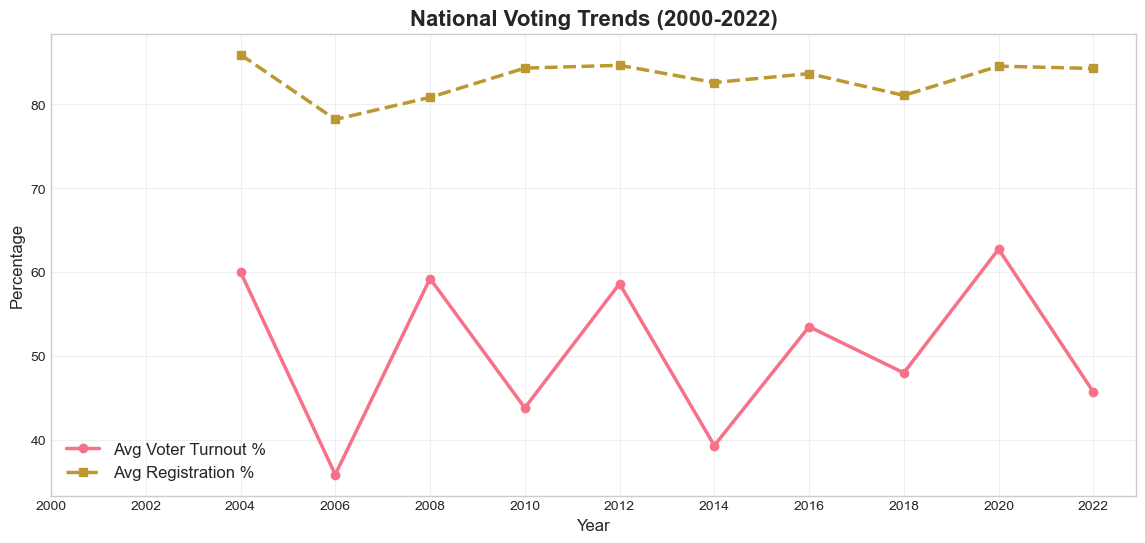

Saved partisan_index_trends.png


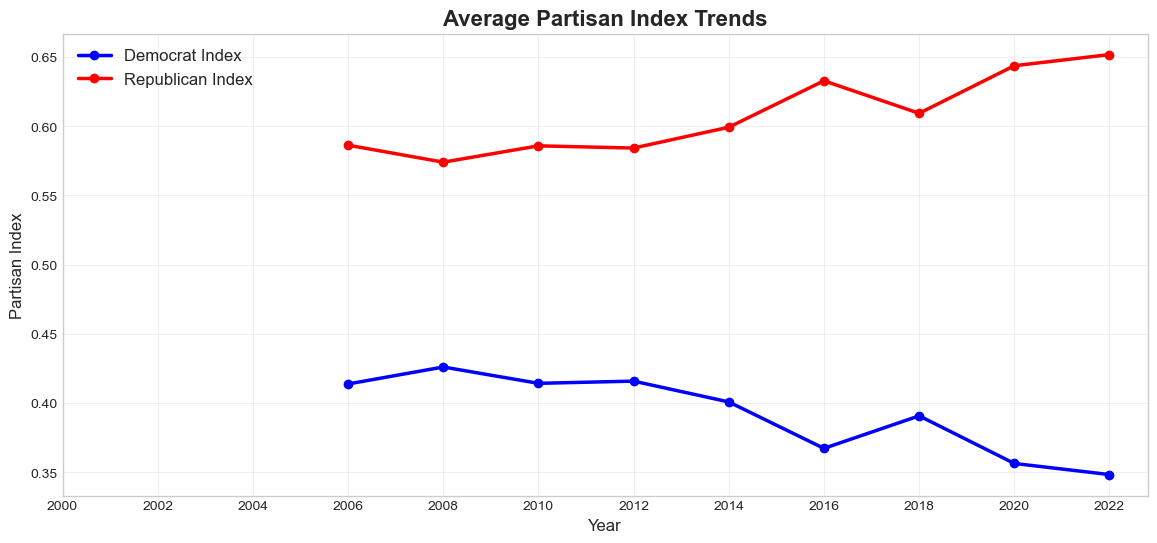

Saved turnout_distribution.png


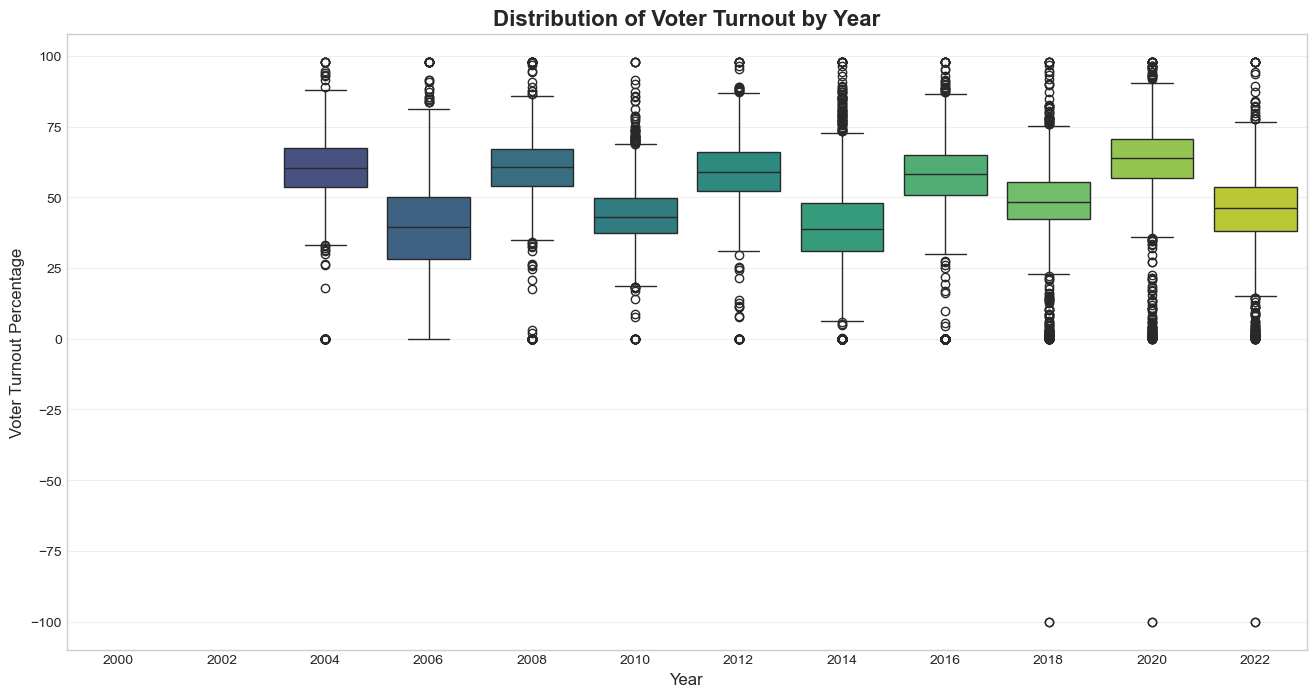

Saved correlation_heatmap.png


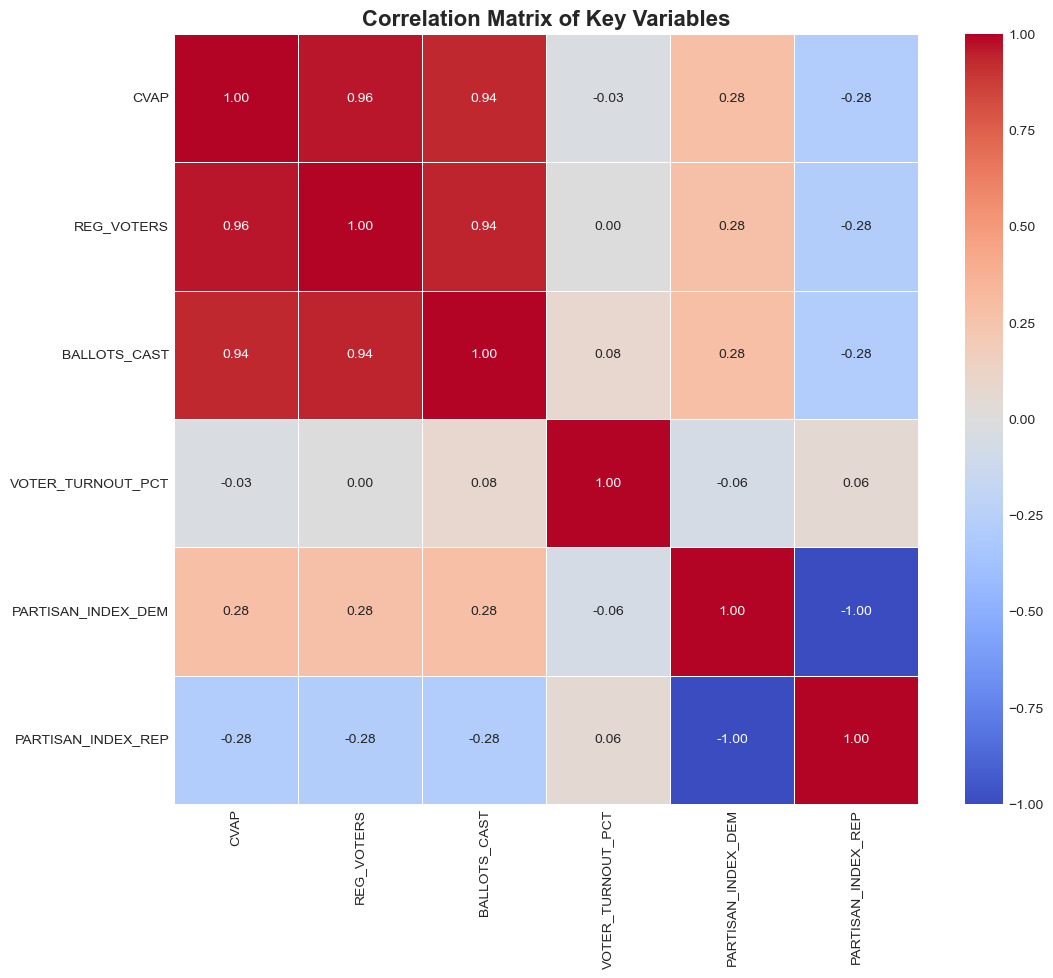

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure plots display inline in the notebook
%matplotlib inline

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def load_and_process_data(filepath):
    if not os.path.exists(filepath):
        print(f"Error: File {filepath} not found.")
        return None
    
    try:
        df = pd.read_parquet(filepath)
        print(f"Successfully loaded {filepath}")
        return df
    except Exception as e:
        print(f"Error loading parquet file: {e}")
        # Try loading csv if parquet fails
        csv_path = filepath.replace('.parquet', '.csv')
        if os.path.exists(csv_path):
            print(f"Trying CSV: {csv_path}")
            return pd.read_csv(csv_path)
        return None

def convert_to_percentage(df, cols):
    for col in cols:
        if col in df.columns:
            # Check if values are likely ratios (0-1) rather than percentages (0-100)
            # Using mean < 1.5 to be safe against outliers (e.g. >100% turnout in bad data)
            if df[col].mean() < 1.5:
                print(f"Converting {col} to percentage (multiplying by 100)")
                df[col] = df[col] * 100
    return df

def run_eda():
    filepath = '../data/processed/voting_population_cleaned.parquet'
    voting_pop_data = load_and_process_data(filepath)
    
    if voting_pop_data is None:
        return

    # Create plots directory
    plots_dir = '../plots'
    os.makedirs(plots_dir, exist_ok=True)
    print(f"Saving plots to {plots_dir}/ directory...")

    # Columns to check for percentage conversion
    pct_cols = ['REG_VOTERS_PCT', 'VOTER_TURNOUT_PCT', 'REG_VOTER_TURNOUT_PCT']
    voting_pop_data = convert_to_percentage(voting_pop_data, pct_cols)

    # 1. Voter Turnout Trends Over Time
    plt.figure(figsize=(14, 6))
    annual_stats = voting_pop_data.groupby('YEAR')[['VOTER_TURNOUT_PCT', 'REG_VOTERS_PCT']].mean().reset_index()
    
    plt.plot(annual_stats['YEAR'], annual_stats['VOTER_TURNOUT_PCT'], marker='o', linewidth=2.5, label='Avg Voter Turnout %')
    plt.plot(annual_stats['YEAR'], annual_stats['REG_VOTERS_PCT'], marker='s', linewidth=2.5, linestyle='--', label='Avg Registration %')
    
    plt.title('National Voting Trends (2000-2022)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(annual_stats['YEAR'])
    
    # Save AND Show
    plt.savefig(os.path.join(plots_dir, 'voter_turnout_trends.png'))
    print("Saved voter_turnout_trends.png")
    plt.show() 

    # 2. Partisan Index Trends
    plt.figure(figsize=(14, 6))
    partisan_stats = voting_pop_data.groupby('YEAR')[['PARTISAN_INDEX_DEM', 'PARTISAN_INDEX_REP']].mean().reset_index()
    
    plt.plot(partisan_stats['YEAR'], partisan_stats['PARTISAN_INDEX_DEM'], marker='o', color='blue', linewidth=2.5, label='Democrat Index')
    plt.plot(partisan_stats['YEAR'], partisan_stats['PARTISAN_INDEX_REP'], marker='o', color='red', linewidth=2.5, label='Republican Index')
    
    plt.title('Average Partisan Index Trends', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Partisan Index', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(partisan_stats['YEAR'])
    
    plt.savefig(os.path.join(plots_dir, 'partisan_index_trends.png'))
    print("Saved partisan_index_trends.png")
    plt.show()

    # 3. Distribution of Turnout by Year (Boxplot)
    plt.figure(figsize=(16, 8))
    sns.boxplot(x='YEAR', y='VOTER_TURNOUT_PCT', data=voting_pop_data, palette="viridis")
    plt.title('Distribution of Voter Turnout by Year', fontsize=16, fontweight='bold')
    plt.ylabel('Voter Turnout Percentage', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.savefig(os.path.join(plots_dir, 'turnout_distribution.png'))
    print("Saved turnout_distribution.png")
    plt.show()

    # 4. Correlation Heatmap
    plt.figure(figsize=(12, 10))
    corr_cols = ['CVAP', 'REG_VOTERS', 'BALLOTS_CAST', 'VOTER_TURNOUT_PCT', 
                 'PARTISAN_INDEX_DEM', 'PARTISAN_INDEX_REP']
    # Filter only columns that exist
    existing_corr_cols = [c for c in corr_cols if c in voting_pop_data.columns]
    corr_matrix = voting_pop_data[existing_corr_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Key Variables', fontsize=16, fontweight='bold')
    
    plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
    print("Saved correlation_heatmap.png")
    plt.show()

# Run the function
run_eda()